# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Lioneil Diyoel Trystan Tikupadang | 5054251037 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.

df = pd.read_csv("bankruptcy.csv")

# Rapikan nama kolom agar lebih mudah dipanggil.
df.columns = df.columns.str.strip()

print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

print("\nTipe data:")
print(df.dtypes.value_counts())

print("\nInformasi dataset:")
df.info()

print("\nStatistik deskriptif:")
display(df.describe().T)

print("\nTotal missing value:", df.isna().sum().sum())

Jumlah baris : 6819
Jumlah kolom : 96

Tipe data:
float64    93
int64       3
Name: count, dtype: int64

Informasi dataset:
<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7   P

,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
...,...,...,...,...,...,...,...,...
Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0
Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0



Total missing value: 0


Distribusi kelas:
Kelas 0: 6599 data (96.77%)
Kelas 1: 220 data (3.23%)


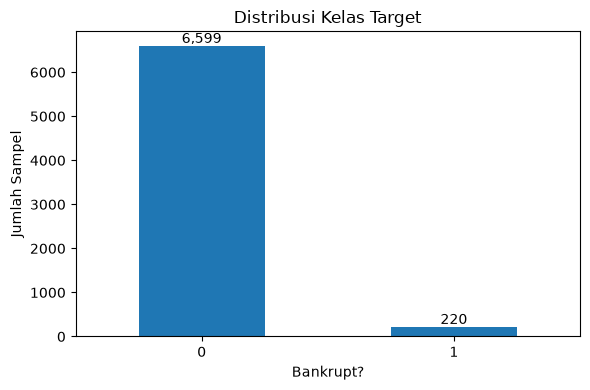

In [3]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

class_counts = df["Bankrupt?"].value_counts().sort_index()
class_percent = df["Bankrupt?"].value_counts(normalize=True).sort_index() * 100

print("Distribusi kelas:")
for cls in class_counts.index:
    print(f"Kelas {cls}: {class_counts[cls]} data ({class_percent[cls]:.2f}%)")

plt.figure(figsize=(6, 4))
ax = class_counts.plot(kind="bar")
plt.xlabel("Bankrupt?")
plt.ylabel("Jumlah Sampel")
plt.title("Distribusi Kelas Target")
plt.xticks(rotation=0)

for i, value in enumerate(class_counts.values):
    ax.text(i, value + class_counts.max() * 0.01, f"{value:,}", ha="center")

plt.tight_layout()
plt.show()

6 fitur dengan korelasi absolut terbesar terhadap target:


,Correlation with Bankrupt?
Net Income to Total Assets,-0.315457
ROA(A) before interest and % after tax,-0.282941
ROA(B) before interest and depreciation after tax,-0.273051
ROA(C) before interest and depreciation before interest,-0.260807
Net worth/Assets,-0.250161
Debt ratio %,0.250161


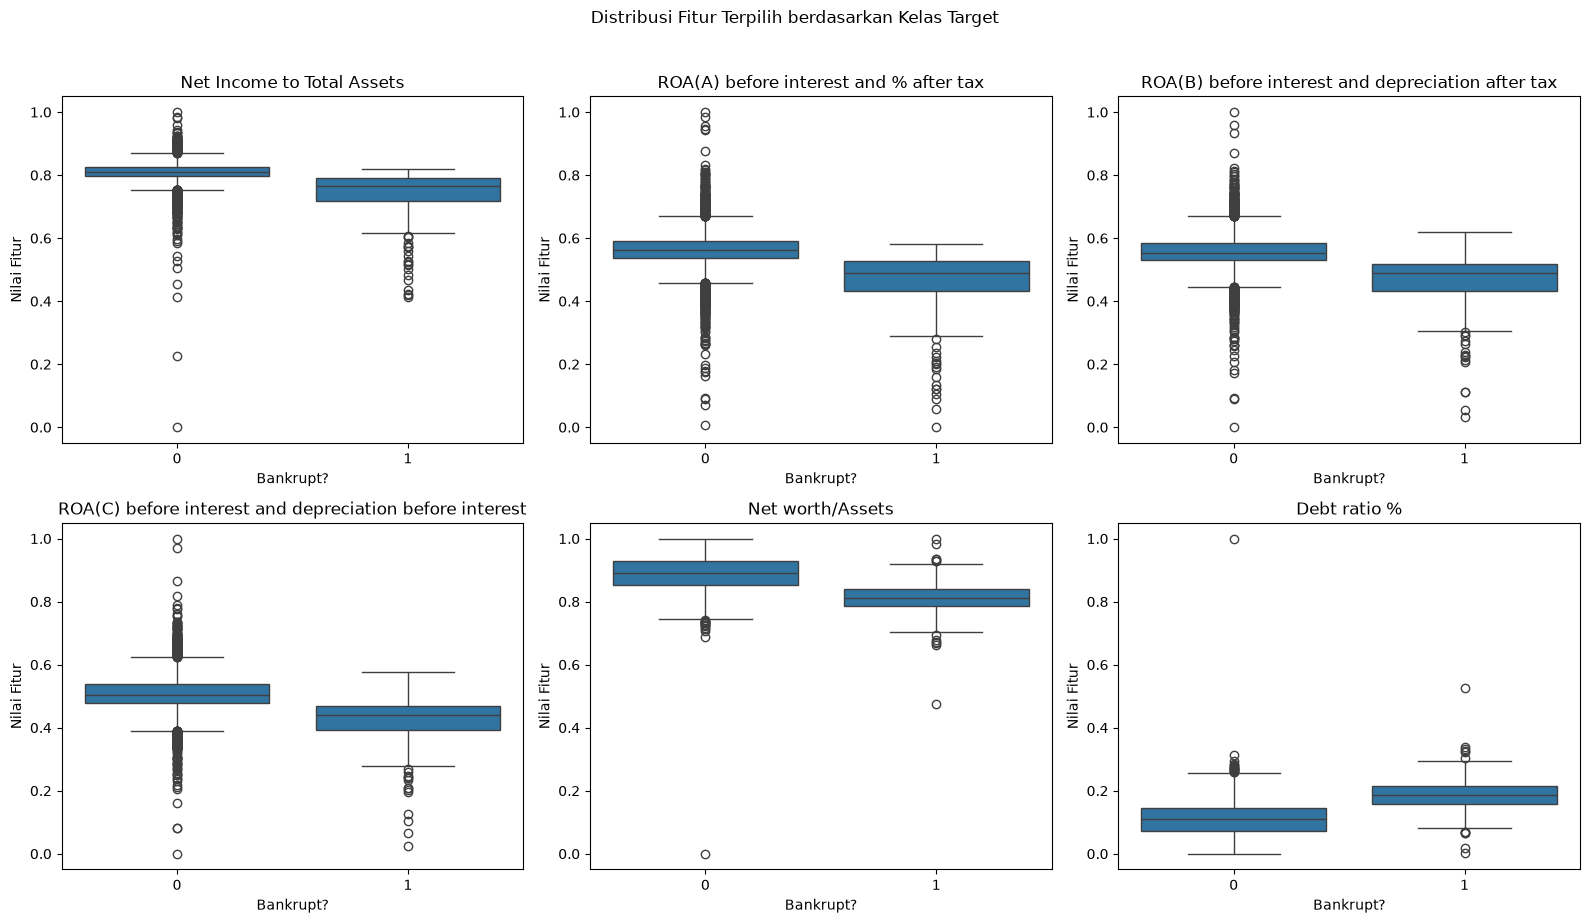

In [4]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.

corr_target = df.corr(numeric_only=True)["Bankrupt?"].drop("Bankrupt?")
top_features = corr_target.abs().sort_values(ascending=False).head(6).index.tolist()

print("6 fitur dengan korelasi absolut terbesar terhadap target:")
display(
    corr_target.loc[top_features]
    .sort_values(key=np.abs, ascending=False)
    .to_frame("Correlation with Bankrupt?")
)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, feature in zip(axes, top_features):
    sns.boxplot(data=df, x="Bankrupt?", y=feature, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("Bankrupt?")
    ax.set_ylabel("Nilai Fitur")

plt.suptitle("Distribusi Fitur Terpilih berdasarkan Kelas Target", y=1.02)
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

- Dataset memiliki **6,819 sampel** dan **96 kolom**.
- Target `Bankrupt?` sangat **imbalanced**: kelas `0` berjumlah **6,599 data (96.77%)**, sedangkan kelas `1` berjumlah **220 data (3.23%)**.
- Tidak ditemukan **missing value** maupun baris duplikat.
- Fitur konstan yang ditemukan adalah **`Net Income Flag`**, sehingga fitur tersebut dihapus karena tidak memberi informasi untuk proses split.
- Seluruh fitur prediktor bertipe numerik, sehingga tidak diperlukan encoding kategorikal.

# 2. Preprocessing

In [5]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

missing = df.isna().sum()
missing_total = int(missing.sum())

print("Total missing value:", missing_total)

if missing_total == 0:
    print("Tidak ada missing value, sehingga tidak diperlukan imputasi.")
else:
    print("Kolom yang memiliki missing value:")
    print(missing[missing > 0])

# Periksa fitur konstan.
constant_features = [
    col for col in df.columns
    if col != "Bankrupt?" and df[col].nunique(dropna=False) <= 1
]

print("\nFitur konstan:", constant_features)

# Hapus fitur konstan karena tidak dapat menghasilkan split informatif.
df_clean = df.drop(columns=constant_features).copy()

Total missing value: 0
Tidak ada missing value, sehingga tidak diperlukan imputasi.

Fitur konstan: ['Net Income Flag']


In [6]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.

categorical_features = df_clean.drop(columns=["Bankrupt?"]).select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Fitur kategorikal:", categorical_features)

if categorical_features:
    # Dataset ini tidak masuk kondisi ini, tetapi langkah berikut adalah
    # encoding yang digunakan bila fitur kategorikal ditemukan.
    df_clean = pd.get_dummies(
        df_clean,
        columns=categorical_features,
        drop_first=False,
        dtype=int
    )
    print("One-hot encoding selesai.")
else:
    print("Tidak ada fitur kategorikal, sehingga encoding tidak diperlukan.")

Fitur kategorikal: []
Tidak ada fitur kategorikal, sehingga encoding tidak diperlukan.


In [7]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = df_clean.drop(columns=["Bankrupt?"])
y = df_clean["Bankrupt?"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah fitur prediktor:", X.shape[1])
print("Jumlah data training  :", X_train.shape[0])
print("Jumlah data testing   :", X_test.shape[0])

print("\nDistribusi target - training:")
print(y_train.value_counts().sort_index())

print("\nDistribusi target - testing:")
print(y_test.value_counts().sort_index())

Jumlah fitur prediktor: 94
Jumlah data training  : 5455
Jumlah data testing   : 1364

Distribusi target - training:
Bankrupt?
0    5279
1     176
Name: count, dtype: int64

Distribusi target - testing:
Bankrupt?
0    1320
1      44
Name: count, dtype: int64


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [8]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.

tree_params = {
    "max_depth": 4,
    "min_samples_leaf": 5,
    "random_state": 42
}

dt_gini = DecisionTreeClassifier(
    criterion="gini",
    **tree_params
)

dt_gini.fit(X_train, y_train)

print("Model Gini berhasil dilatih.")
print("Actual tree depth:", dt_gini.get_depth())
print("Jumlah leaf:", dt_gini.get_n_leaves())

Model Gini berhasil dilatih.
Actual tree depth: 4
Jumlah leaf: 13


In [9]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred_gini = dt_gini.predict(X_test)

print("Jumlah prediksi:", len(y_pred_gini))
print("20 prediksi pertama:", y_pred_gini[:20])

Jumlah prediksi: 1364
20 prediksi pertama: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [10]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.

dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    **tree_params
)

dt_entropy.fit(X_train, y_train)

print("Model Entropy berhasil dilatih.")
print("Actual tree depth:", dt_entropy.get_depth())
print("Jumlah leaf:", dt_entropy.get_n_leaves())

Model Entropy berhasil dilatih.
Actual tree depth: 4
Jumlah leaf: 15


In [11]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred_entropy = dt_entropy.predict(X_test)

print("Jumlah prediksi:", len(y_pred_entropy))
print("20 prediksi pertama:", y_pred_entropy[:20])

Jumlah prediksi: 1364
20 prediksi pertama: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [12]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).

depths = [1, 2, 3, 4, 5, 10, None]

depth_models = {}

for depth in depths:
    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        min_samples_leaf=5,
        random_state=42
    )
    model.fit(X_train, y_train)
    depth_models[depth] = model

print("Eksperimen selesai untuk max_depth:", depths)

Eksperimen selesai untuk max_depth: [1, 2, 3, 4, 5, 10, None]


In [13]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.

depth_results = []

for depth, model in depth_models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    depth_results.append({
        "max_depth": "None" if depth is None else depth,
        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "test_accuracy": accuracy_score(y_test, y_test_pred),
        # F1 kelas 1 ditambahkan agar efek imbalance juga terlihat.
        "train_f1_class_1": f1_score(y_train, y_train_pred, pos_label=1, zero_division=0),
        "test_f1_class_1": f1_score(y_test, y_test_pred, pos_label=1, zero_division=0)
    })

depth_results_df = pd.DataFrame(depth_results)

display(depth_results_df.style.format({
    "train_accuracy": "{:.4f}",
    "test_accuracy": "{:.4f}",
    "train_f1_class_1": "{:.4f}",
    "test_f1_class_1": "{:.4f}"
}))

,max_depth,train_accuracy,test_accuracy,train_f1_class_1,test_f1_class_1
0,1,0.9677,0.9677,0.0000,0.0000
1,2,0.9677,0.9677,0.0000,0.0000
2,3,0.9683,0.9699,0.1307,0.2264
3,4,0.9729,0.9707,0.5226,0.4595
4,5,0.9743,0.9663,0.5906,0.4390
5,10,0.9855,0.9619,0.7508,0.3500
6,None,0.9903,0.9575,0.8446,0.3095


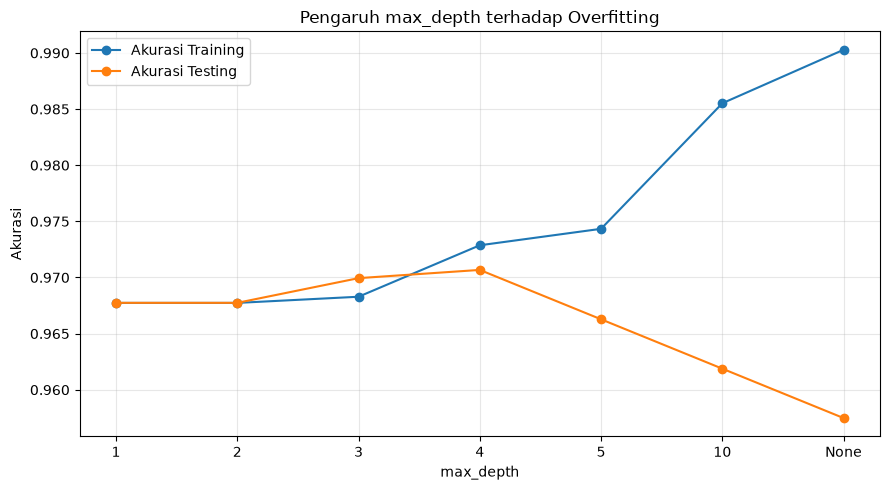

In [14]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).

plt.figure(figsize=(9, 5))

plt.plot(
    depth_results_df["max_depth"].astype(str),
    depth_results_df["train_accuracy"],
    marker="o",
    label="Akurasi Training"
)

plt.plot(
    depth_results_df["max_depth"].astype(str),
    depth_results_df["test_accuracy"],
    marker="o",
    label="Akurasi Testing"
)

plt.xlabel("max_depth")
plt.ylabel("Akurasi")
plt.title("Pengaruh max_depth terhadap Overfitting")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [15]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

metrics_comparison = pd.DataFrame({
    "Accuracy": [
        accuracy_score(y_test, y_pred_gini),
        accuracy_score(y_test, y_pred_entropy)
    ],
    "Precision (Class 1)": [
        precision_score(y_test, y_pred_gini, pos_label=1, zero_division=0),
        precision_score(y_test, y_pred_entropy, pos_label=1, zero_division=0)
    ],
    "Recall (Class 1)": [
        recall_score(y_test, y_pred_gini, pos_label=1, zero_division=0),
        recall_score(y_test, y_pred_entropy, pos_label=1, zero_division=0)
    ],
    "F1-Score (Class 1)": [
        f1_score(y_test, y_pred_gini, pos_label=1, zero_division=0),
        f1_score(y_test, y_pred_entropy, pos_label=1, zero_division=0)
    ],
    "Macro F1": [
        f1_score(y_test, y_pred_gini, average="macro", zero_division=0),
        f1_score(y_test, y_pred_entropy, average="macro", zero_division=0)
    ]
}, index=["Gini", "Entropy"])

display(metrics_comparison.style.format("{:.4f}"))

print("\nClassification Report - Gini")
print(classification_report(y_test, y_pred_gini, digits=4, zero_division=0))

print("Classification Report - Entropy")
print(classification_report(y_test, y_pred_entropy, digits=4, zero_division=0))

,Accuracy,Precision (Class 1),Recall (Class 1),F1-Score (Class 1),Macro F1
Gini,0.9692,0.5833,0.1591,0.2500,0.6171
Entropy,0.9707,0.5667,0.3864,0.4595,0.7222



Classification Report - Gini
              precision    recall  f1-score   support

           0     0.9726    0.9962    0.9843      1320
           1     0.5833    0.1591    0.2500        44

    accuracy                         0.9692      1364
   macro avg     0.7780    0.5777    0.6171      1364
weighted avg     0.9601    0.9692    0.9606      1364

Classification Report - Entropy
              precision    recall  f1-score   support

           0     0.9798    0.9902    0.9849      1320
           1     0.5667    0.3864    0.4595        44

    accuracy                         0.9707      1364
   macro avg     0.7732    0.6883    0.7222      1364
weighted avg     0.9664    0.9707    0.9680      1364



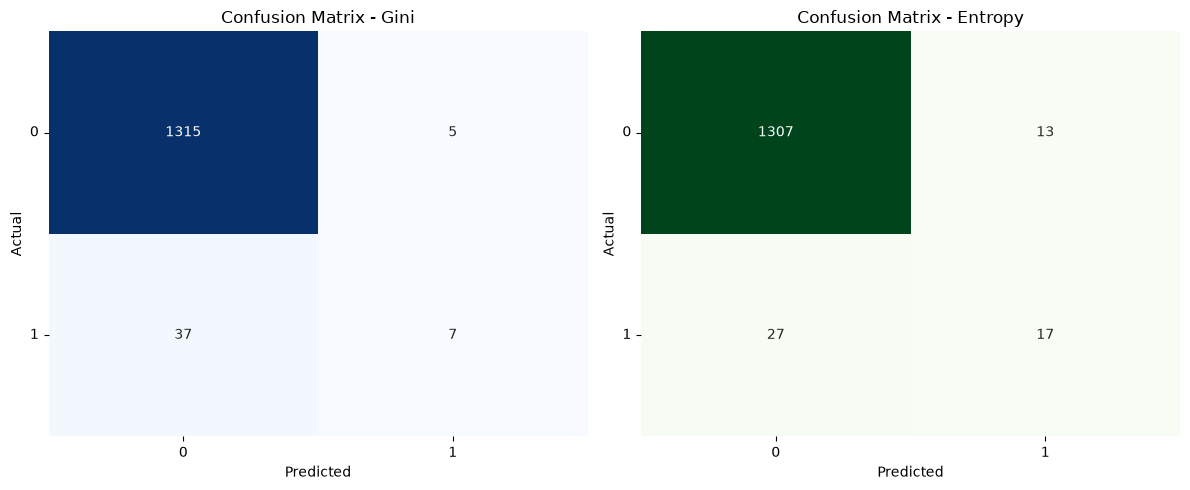

Confusion matrix Gini:
 [[1315    5]
 [  37    7]]

Confusion matrix Entropy:
 [[1307   13]
 [  27   17]]


In [16]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.

cm_gini = confusion_matrix(y_test, y_pred_gini)
cm_entropy = confusion_matrix(y_test, y_pred_entropy)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_gini,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix - Gini")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_xticklabels(["0", "1"])
axes[0].set_yticklabels(["0", "1"], rotation=0)

sns.heatmap(
    cm_entropy,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    ax=axes[1]
)
axes[1].set_title("Confusion Matrix - Entropy")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_xticklabels(["0", "1"])
axes[1].set_yticklabels(["0", "1"], rotation=0)

plt.tight_layout()
plt.show()

print("Confusion matrix Gini:\n", cm_gini)
print("\nConfusion matrix Entropy:\n", cm_entropy)

Model untuk visualisasi: Entropy
F1-score class 1: 0.4594594594594595


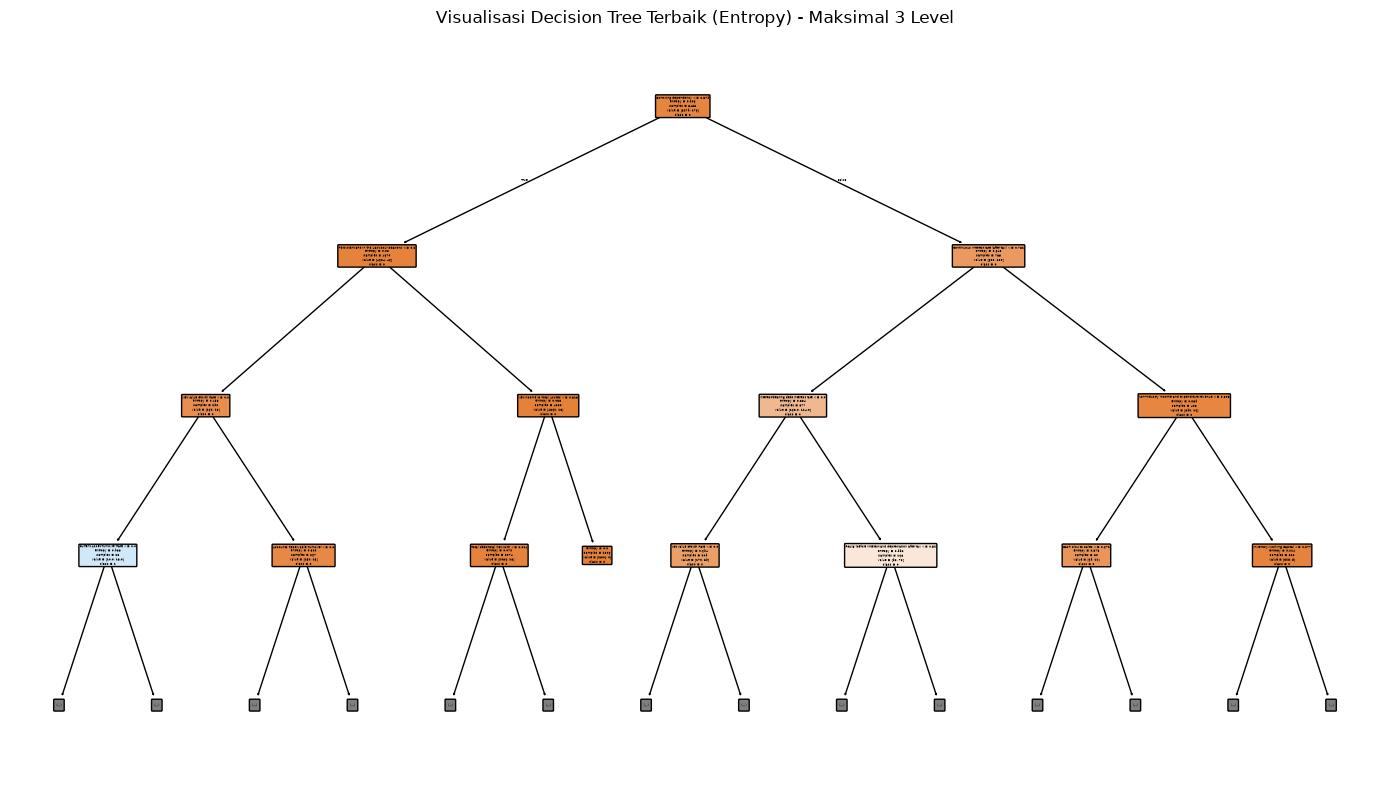

In [17]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.

f1_gini = f1_score(y_test, y_pred_gini, pos_label=1, zero_division=0)
f1_entropy = f1_score(y_test, y_pred_entropy, pos_label=1, zero_division=0)

if f1_entropy >= f1_gini:
    best_model = dt_entropy
    best_model_name = "Entropy"
else:
    best_model = dt_gini
    best_model_name = "Gini"

print("Model untuk visualisasi:", best_model_name)
print("F1-score class 1:", max(f1_gini, f1_entropy))

plt.figure(figsize=(14, 8))
plot_tree(
    best_model,
    filled=True,
    rounded=True,
    feature_names=X.columns,
    class_names=["0", "1"],
    max_depth=3
)
plt.title(f"Visualisasi Decision Tree Terbaik ({best_model_name}) - Maksimal 3 Level")
plt.tight_layout()
plt.show()

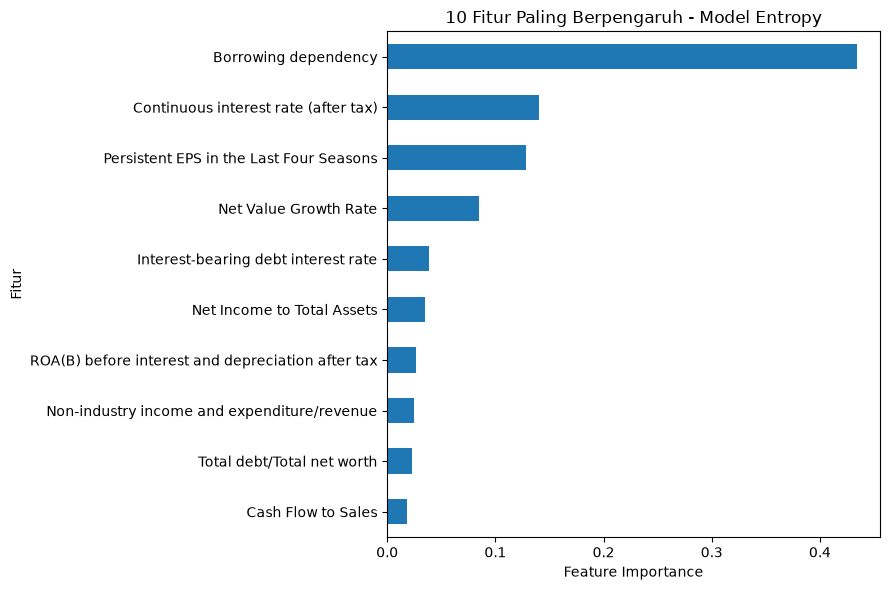

,Feature Importance
Borrowing dependency,0.4339
Continuous interest rate (after tax),0.1399
Persistent EPS in the Last Four Seasons,0.1284
Net Value Growth Rate,0.0851
Interest-bearing debt interest rate,0.0390
Net Income to Total Assets,0.0351
ROA(B) before interest and depreciation after tax,0.0269
Non-industry income and expenditure/revenue,0.0249
Total debt/Total net worth,0.0230
Cash Flow to Sales,0.0185


In [18]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.

feature_importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_importances = feature_importances.head(10).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
top_importances.plot(kind="barh")
plt.xlabel("Feature Importance")
plt.ylabel("Fitur")
plt.title(f"10 Fitur Paling Berpengaruh - Model {best_model_name}")
plt.tight_layout()
plt.show()

display(
    feature_importances.head(10)
    .to_frame("Feature Importance")
    .style.format("{:.4f}"))

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Dataset memiliki 6.819 sampel dan 96 kolom. Target `Bankrupt?` terdiri dari 6.599 data kelas 0 (96,77%) dan 220 data kelas 1 (3,23%), sehingga distribusi kelas sangat imbalanced. Tidak ditemukan missing value maupun baris duplikat. Fitur `Net Income Flag` hanya memiliki satu nilai yang sama untuk seluruh sampel, sehingga dihapus karena tidak dapat membantu membuat split. Setelah preprocessing, model menggunakan 94 fitur prediktor dan seluruhnya numerik. Data dibagi menjadi 5.455 data training dan 1.364 data testing dengan `stratify=y`, sehingga proporsi kelas tetap terjaga.

#### Perbandingan Gini vs Entropy

Dengan parameter yang sama (`max_depth=4`, `min_samples_leaf=5`, `random_state=42`), hasil testing adalah:

- Gini: accuracy 0.9692, precision kelas 1 0.5833, recall kelas 1 0.1591, F1 kelas 1 0.2500.
- Entropy: accuracy 0.9707, precision kelas 1 0.5667, recall kelas 1 0.3864, F1 kelas 1 0.4595.

Perbedaan accuracy hanya sekitar 0.15 percentage point, sehingga dari accuracy keseluruhan keduanya tampak mirip. Namun untuk kelas `1` yang merupakan kelas minoritas, Entropy memiliki recall 38.64% dibanding Gini 15.91% dan F1 45.95% dibanding Gini 25.00%.

Confusion matrix menjelaskan perbedaan tersebut. Gini menghasilkan 7 true positive dan 37 false negative, sedangkan Entropy menghasilkan 17 true positive dan 27 false negative. Entropy juga menghasilkan lebih banyak false positive (13) dibanding Gini (5). Jadi perbedaan utama antara kedua kriteria pada eksperimen ini terlihat pada trade-off deteksi kelas minoritas, bukan pada accuracy keseluruhan.

Secara konsep, Gini mengukur impurity pada node, sedangkan Entropy mengukur ketidakpastian distribusi kelas melalui Information Gain. Pada dataset dan pengaturan hyperparameter ini, Entropy menghasilkan split yang lebih membantu memisahkan sebagian sampel kelas bankrupt.

#### Pengaruh `max_depth` terhadap overfitting

Pada eksperimen regularisasi, criterion Entropy dan `min_samples_leaf=5` dipertahankan, sedangkan `max_depth` divariasikan.

Akurasi training meningkat dari 96.77% pada depth 1 menjadi 99.03% pada `None`. Sementara itu, accuracy testing mencapai nilai tertinggi 97.07% pada depth 4, lalu turun menjadi 96.63% pada depth 5, 96.19% pada depth 10, dan 95.75% pada `None`.

Dengan demikian, gejala overfitting mulai terlihat sekitar `max_depth=5`. Ciri-cirinya adalah akurasi training terus naik, sementara akurasi testing mulai turun. Pada `max_depth=None`, training accuracy mencapai 99.03%, tetapi testing accuracy turun menjadi 95.75%.

F1 kelas 1 juga memperlihatkan pola yang sama: pada depth 4 F1 testing adalah 45.95%, kemudian menjadi 43.90%, 35.00%, dan 30.95%. Hal ini sesuai dengan materi bahwa tree yang terlalu dalam dapat menyesuaikan data training secara berlebihan sehingga kemampuan generalisasi menurun.

#### Fitur paling berpengaruh

Model yang dipilih untuk visualisasi adalah Entropy, berdasarkan F1-score kelas 1 pada perbandingan Gini dan Entropy. Lima feature importance tertinggi adalah:

1. Borrowing dependency: 43.39%
2. Continuous interest rate (after tax): 13.99%
3. Persistent EPS in the Last Four Seasons: 12.84%
4. Net Value Growth Rate: 8.51%
5. Interest-bearing debt interest rate: 3.90%

Feature importance menunjukkan seberapa besar fitur berkontribusi dalam pengurangan impurity pada tree yang dilatih. Nilai tersebut bukan hubungan sebab-akibat dan tidak berarti fitur yang lebih penting secara statistik pasti menjadi penyebab kebangkrutan.

Karena dataset sangat imbalanced, accuracy tidak sebaiknya dibaca sendirian. Precision, recall, dan F1 kelas `1` perlu diperhatikan karena tujuan klasifikasi juga mencakup kemampuan mendeteksi sampel bankrupt.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Berdasarkan eksperimen pada dataset `bankruptcy.csv`, Decision Tree dapat digunakan untuk klasifikasi status `Bankrupt?`. Dataset sangat imbalanced, yaitu hanya 3,23% sampel berada pada kelas bankrupt, sehingga evaluasi perlu melihat metrik selain accuracy.

Dengan pengaturan `max_depth=4` dan `min_samples_leaf=5`, Gini menghasilkan accuracy **96.92%**, sedangkan Entropy menghasilkan **97.07%**. Meskipun accuracy keduanya hampir sama, Entropy menghasilkan recall dan F1 kelas `1` yang lebih tinggi pada eksperimen ini. Oleh karena itu, model yang digunakan untuk visualisasi dan analisis feature importance adalah model Entropy.

Eksperimen `max_depth` menunjukkan bahwa pembatasan kedalaman berperan dalam mengurangi overfitting. Pada depth 4, testing accuracy mencapai **97.07%** pada variasi yang diuji. Mulai sekitar depth 5, training accuracy terus naik tetapi testing accuracy menurun. Ketika tree dibiarkan tanpa batas (`max_depth=None`), training accuracy menjadi **99.03%**, sedangkan testing accuracy turun menjadi **95.75%**.

### Saran

Eksperimen selanjutnya dapat mengikuti saran pada materi dengan mencoba post-pruning menggunakan `ccp_alpha`**, membandingkan    `min_samples_leaf` dan `min_samples_split`, serta mengevaluasi teknik penanganan class imbalance. Untuk eksperimen lanjutan, preprocessing yang menggunakan statistik data sebaiknya tetap dipelajari hanya dari data training agar tidak terjadi data leakage.